In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

_cwd = Path.cwd().resolve()
if (_cwd / "data" / "HumidityLookup.csv").exists():
    DATA_DIR = _cwd / "data"
elif (_cwd.parent / "data" / "HumidityLookup.csv").exists():
    DATA_DIR = _cwd.parent / "data"
else:
    DATA_DIR = _cwd.parent / "data"

sns.set_theme(style="whitegrid")


In [2]:
df_Hum = pd.read_csv(DATA_DIR / "HumidityLookup.csv")
df_Ph = pd.read_csv(DATA_DIR / "PHRangeLookup.csv")
df_Soil = pd.read_csv(DATA_DIR / "SoilTextureLookup.csv")
df_Var = pd.read_csv(DATA_DIR / "PlantVariety.csv")
df_PlantType = pd.read_csv(DATA_DIR / "PlantTypeLookup.csv")
df_Hard = pd.read_csv(DATA_DIR / "PlantHardinessZoneLookup.csv")
df_Saline = pd.read_csv(DATA_DIR / "SalinityLookup.csv")
df_OrgMat = pd.read_csv(DATA_DIR / "OrganicMatterLookup.csv")
df_plant = pd.read_csv(DATA_DIR / "Plant.csv")


In [3]:
# Unify hardiness zones: aggregate temperature ranges by numeric zone
df_Hard = df_Hard.copy()
df_Hard["UnifiedZone"] = df_Hard["Zone"].astype(str).str.extract(r"(\d+)")
merged_zone_data = (
    df_Hard.dropna(subset=["UnifiedZone"])
    .groupby("UnifiedZone", as_index=False)
    .agg({"TemperatureStartRange": "min", "TemperatureEndRange": "max"})
)
merged_zone_data["UnifiedZone"] = merged_zone_data["UnifiedZone"].astype(float)
df_Hard_new = merged_zone_data


In [4]:
# Join the dataframes
result = (
    df_plant
    # Join PH Range Lookup
    .merge(df_Ph[['PHRangeID', 'PHRange', 'SoilType']], on='PHRangeID', how='left')
    # Join Unified Plant Hardiness Zones Lookup (matching ZoneID with UnifiedZone)
    .merge(df_Hard_new[['UnifiedZone', 'TemperatureStartRange', 'TemperatureEndRange']], 
           left_on='ZoneID', right_on='UnifiedZone', how='left')
    # Join Plant Type Lookup
    .merge(df_PlantType[['PlantTypeID', 'PlantType']], on='PlantTypeID', how='left')
    # Join Soil Texture Lookup
    .merge(df_Soil[['SoilTextureID', 'SoilTexture']], on='SoilTextureID', how='left')
    # Join Humidity Lookup
    .merge(df_Hum[['HumidityID', 'Classification']], on='HumidityID', how='left')
    # Join Organic Matter Lookup
    .merge(df_OrgMat[['OrganicMatterID', 'OrganicMatterContent']], on='OrganicMatterID', how='left')
    # Join Salinity Lookup
    .merge(df_Saline[['SalinityLevelID', 'SalinityLevel', 'Classification']], 
           on='SalinityLevelID', how='left', suffixes=('', '_Salinity'))
    # Join Plant Variety
    .merge(df_Var[['PlantID', 'PlantVarietyName']], on='PlantID', how='left')
)

# Drop unnecessary columns
result = result.drop(columns=['PlantDescription'])

# Display the result
print(result.head())

   PlantID PlantName  SoilTextureID  PHRangeID  OrganicMatterID  \
0        2   Lettuce              1          3                3   
1        2   Lettuce              1          3                3   
2        2   Lettuce              1          3                3   
3        2   Lettuce              1          3                3   
4        2   Lettuce              1          3                3   

   SalinityLevelID  ZoneID  HumidityID  PlantTypeID    PHRange  ...  \
0                2     8.0           2            2  6.6 - 7.0  ...   
1                2     8.0           2            2  6.6 - 7.0  ...   
2                2     8.0           2            2  6.6 - 7.0  ...   
3                2     8.0           2            2  6.6 - 7.0  ...   
4                2     8.0           2            2  6.6 - 7.0  ...   

  UnifiedZone  TemperatureStartRange  TemperatureEndRange  PlantType  \
0         8.0                   15.0                 22.0      Fruit   
1         8.0             

In [5]:
# Optional: export joined table
# result.to_csv(DATA_DIR / "Joined_Data.csv", index=False)


In [6]:
final_df = result

In [7]:
final_df.describe()

,PlantID,SoilTextureID,PHRangeID,OrganicMatterID,SalinityLevelID,ZoneID,HumidityID,PlantTypeID,UnifiedZone,TemperatureStartRange,TemperatureEndRange
count,2002.000000,2002.000000,2002.000000,2002.000000,2002.000000,2002.000000,2002.000000,2002.000000,2002.000000,2002.000000,2002.000000
mean,2.828172,1.927073,2.444056,2.091409,1.469530,9.019980,2.059441,1.993506,9.019980,21.833167,30.199800
std,0.801950,0.818133,1.154318,0.819634,0.499195,0.820527,0.820138,0.814939,0.820527,6.284218,7.541061
min,2.000000,1.000000,1.000000,1.000000,1.000000,8.000000,1.000000,1.000000,8.000000,15.000000,22.000000
25%,2.000000,1.000000,1.000000,1.000000,1.000000,8.000000,1.000000,1.000000,8.000000,15.000000,22.000000
50%,3.000000,2.000000,2.000000,2.000000,1.000000,9.000000,2.000000,2.000000,9.000000,20.000000,28.000000
75%,3.750000,3.000000,4.000000,3.000000,2.000000,10.000000,3.000000,3.000000,10.000000,30.000000,40.000000
max,4.000000,3.000000,4.000000,3.000000,2.000000,10.000000,3.000000,3.000000,10.000000,30.000000,40.000000


In [8]:
final_df.isnull().sum()

PlantID                    0
PlantName                  0
SoilTextureID              0
PHRangeID                  0
OrganicMatterID            0
SalinityLevelID            0
ZoneID                     0
HumidityID                 0
PlantTypeID                0
PHRange                    0
SoilType                   0
UnifiedZone                0
TemperatureStartRange      0
TemperatureEndRange        0
PlantType                  0
SoilTexture                0
Classification             0
OrganicMatterContent       0
SalinityLevel              0
Classification_Salinity    0
PlantVarietyName           0
dtype: int64

In [9]:
# Drop rows with any missing values in the DataFrame
cleaned_df = final_df.dropna()

# Display the number of rows before and after cleaning
print("Rows before cleaning:", final_df.shape[0])
print("Rows after cleaning:", cleaned_df.shape[0])


Rows before cleaning: 2002
Rows after cleaning: 2002


In [10]:
cleaned_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2002 entries, 0 to 2001
Data columns (total 21 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   PlantID                  2002 non-null   int64  
 1   PlantName                2002 non-null   object 
 2   SoilTextureID            2002 non-null   int64  
 3   PHRangeID                2002 non-null   int64  
 4   OrganicMatterID          2002 non-null   int64  
 5   SalinityLevelID          2002 non-null   int64  
 6   ZoneID                   2002 non-null   float64
 7   HumidityID               2002 non-null   int64  
 8   PlantTypeID              2002 non-null   int64  
 9   PHRange                  2002 non-null   object 
 10  SoilType                 2002 non-null   object 
 11  UnifiedZone              2002 non-null   float64
 12  TemperatureStartRange    2002 non-null   float64
 13  TemperatureEndRange      2002 non-null   float64
 14  PlantType               

In [11]:
# Optional: export cleaned table
# cleaned_df.to_csv(DATA_DIR / "cleaned_df.csv", index=False)


In [12]:

cleaned_df['OrganicMatterContent'] = cleaned_df['OrganicMatterContent'].replace({
    'Moderate (2% - 4%)': 'Moderate',
    'Low (1% - 2%)': 'Low',
    'High (4% - 6%)': 'High'
})
#Print the updated DataFrame
cleaned_df

,PlantID,PlantName,SoilTextureID,PHRangeID,OrganicMatterID,SalinityLevelID,ZoneID,HumidityID,PlantTypeID,PHRange,...,UnifiedZone,TemperatureStartRange,TemperatureEndRange,PlantType,SoilTexture,Classification,OrganicMatterContent,SalinityLevel,Classification_Salinity,PlantVarietyName
0,2,Lettuce,1,3,3,2,8.0,2,2,6.6 - 7.0,...,8.0,15.0,22.0,Fruit,Sandy Soil,Moderate,High,>= 2,Saline,Little Gem
1,2,Lettuce,1,3,3,2,8.0,2,2,6.6 - 7.0,...,8.0,15.0,22.0,Fruit,Sandy Soil,Moderate,High,>= 2,Saline,Looseleaf
2,2,Lettuce,1,3,3,2,8.0,2,2,6.6 - 7.0,...,8.0,15.0,22.0,Fruit,Sandy Soil,Moderate,High,>= 2,Saline,Oak Leaf
3,2,Lettuce,1,3,3,2,8.0,2,2,6.6 - 7.0,...,8.0,15.0,22.0,Fruit,Sandy Soil,Moderate,High,>= 2,Saline,Crisphead
4,2,Lettuce,1,3,3,2,8.0,2,2,6.6 - 7.0,...,8.0,15.0,22.0,Fruit,Sandy Soil,Moderate,High,>= 2,Saline,Red Leaf Lettuce
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1997,4,Basil,1,1,2,1,10.0,3,1,5.5 - 6.0,...,10.0,30.0,40.0,Vegetable,Sandy Soil,High,Moderate,< 2,Non-Saline,Sweet
1998,3,Tomato,1,3,2,1,10.0,3,2,6.6 - 7.0,...,10.0,30.0,40.0,Fruit,Sandy Soil,High,Moderate,< 2,Non-Saline,Cherry
1999,3,Tomato,1,3,2,1,10.0,3,2,6.6 - 7.0,...,10.0,30.0,40.0,Fruit,Sandy Soil,High,Moderate,< 2,Non-Saline,Roma
2000,3,Tomato,1,3,2,1,10.0,3,2,6.6 - 7.0,...,10.0,30.0,40.0,Fruit,Sandy Soil,High,Moderate,< 2,Non-Saline,Beefsteak


In [13]:
cleaned_df['PlantType'].value_counts()

PlantType
Fruit        673
Vegetable    671
Herb         658
Name: count, dtype: int64

In [14]:
# Create a copy of the cleaned_df
cleaned_df_copy4 = cleaned_df.copy()

# Check the copy to confirm it matches the original
cleaned_df_copy4.head()


,PlantID,PlantName,SoilTextureID,PHRangeID,OrganicMatterID,SalinityLevelID,ZoneID,HumidityID,PlantTypeID,PHRange,...,UnifiedZone,TemperatureStartRange,TemperatureEndRange,PlantType,SoilTexture,Classification,OrganicMatterContent,SalinityLevel,Classification_Salinity,PlantVarietyName
0,2,Lettuce,1,3,3,2,8.0,2,2,6.6 - 7.0,...,8.0,15.0,22.0,Fruit,Sandy Soil,Moderate,High,>= 2,Saline,Little Gem
1,2,Lettuce,1,3,3,2,8.0,2,2,6.6 - 7.0,...,8.0,15.0,22.0,Fruit,Sandy Soil,Moderate,High,>= 2,Saline,Looseleaf
2,2,Lettuce,1,3,3,2,8.0,2,2,6.6 - 7.0,...,8.0,15.0,22.0,Fruit,Sandy Soil,Moderate,High,>= 2,Saline,Oak Leaf
3,2,Lettuce,1,3,3,2,8.0,2,2,6.6 - 7.0,...,8.0,15.0,22.0,Fruit,Sandy Soil,Moderate,High,>= 2,Saline,Crisphead
4,2,Lettuce,1,3,3,2,8.0,2,2,6.6 - 7.0,...,8.0,15.0,22.0,Fruit,Sandy Soil,Moderate,High,>= 2,Saline,Red Leaf Lettuce


In [15]:
from sklearn.preprocessing import LabelEncoder

# Create a LabelEncoder object
label_encoder = LabelEncoder()

# Convert the 'PlantType' column to numeric labels
cleaned_df_copy4['PlantType'] = label_encoder.fit_transform(cleaned_df_copy4['PlantType'])

# Check the result
cleaned_df_copy4.head()


,PlantID,PlantName,SoilTextureID,PHRangeID,OrganicMatterID,SalinityLevelID,ZoneID,HumidityID,PlantTypeID,PHRange,...,UnifiedZone,TemperatureStartRange,TemperatureEndRange,PlantType,SoilTexture,Classification,OrganicMatterContent,SalinityLevel,Classification_Salinity,PlantVarietyName
0,2,Lettuce,1,3,3,2,8.0,2,2,6.6 - 7.0,...,8.0,15.0,22.0,0,Sandy Soil,Moderate,High,>= 2,Saline,Little Gem
1,2,Lettuce,1,3,3,2,8.0,2,2,6.6 - 7.0,...,8.0,15.0,22.0,0,Sandy Soil,Moderate,High,>= 2,Saline,Looseleaf
2,2,Lettuce,1,3,3,2,8.0,2,2,6.6 - 7.0,...,8.0,15.0,22.0,0,Sandy Soil,Moderate,High,>= 2,Saline,Oak Leaf
3,2,Lettuce,1,3,3,2,8.0,2,2,6.6 - 7.0,...,8.0,15.0,22.0,0,Sandy Soil,Moderate,High,>= 2,Saline,Crisphead
4,2,Lettuce,1,3,3,2,8.0,2,2,6.6 - 7.0,...,8.0,15.0,22.0,0,Sandy Soil,Moderate,High,>= 2,Saline,Red Leaf Lettuce


In [16]:
# Get the mapping of labels to original categories
label_mapping = dict(zip(label_encoder.classes_, range(len(label_encoder.classes_))))

# Print the mapping
print(label_mapping)


{'Fruit': 0, 'Herb': 1, 'Vegetable': 2}


In [17]:
cleaned_df_copy4['PHRange']

0       6.6 - 7.0
1       6.6 - 7.0
2       6.6 - 7.0
3       6.6 - 7.0
4       6.6 - 7.0
          ...    
1997    5.5 - 6.0
1998    6.6 - 7.0
1999    6.6 - 7.0
2000    6.6 - 7.0
2001    6.6 - 7.0
Name: PHRange, Length: 2002, dtype: object

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Define features (X) and target (y)
X = cleaned_df_copy4.drop(columns=['PlantVarietyName','PlantID', 'SoilTextureID', 'PHRangeID', 'OrganicMatterID', 'SalinityLevelID', 'ZoneID', 'HumidityID', 'PlantTypeID', 'PlantType','PlantName','PHRange'])
y = cleaned_df_copy4['PlantType']

# One-hot encode categorical features
X_encoded = pd.get_dummies(X, drop_first=True)

# Ensure all column names are valid strings
X_encoded.columns = X_encoded.columns.str.replace(r'[^\w\s]', '', regex=True)

# Split the data into training and test sets (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)

# Train the Random Forest model
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

# Make predictions
y_pred_rf = rf_model.predict(X_test)

# Evaluate the model
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print(f"Random Forest Accuracy: {accuracy_rf:.2f}")
print("\nClassification Report for Random Forest:\n")
print(classification_report(y_test, y_pred_rf))


Random Forest Accuracy: 0.70

Classification Report for Random Forest:

              precision    recall  f1-score   support

           0       0.72      0.70      0.71       135
           1       0.69      0.63      0.66       134
           2       0.68      0.77      0.72       132

    accuracy                           0.70       401
   macro avg       0.70      0.70      0.70       401
weighted avg       0.70      0.70      0.70       401



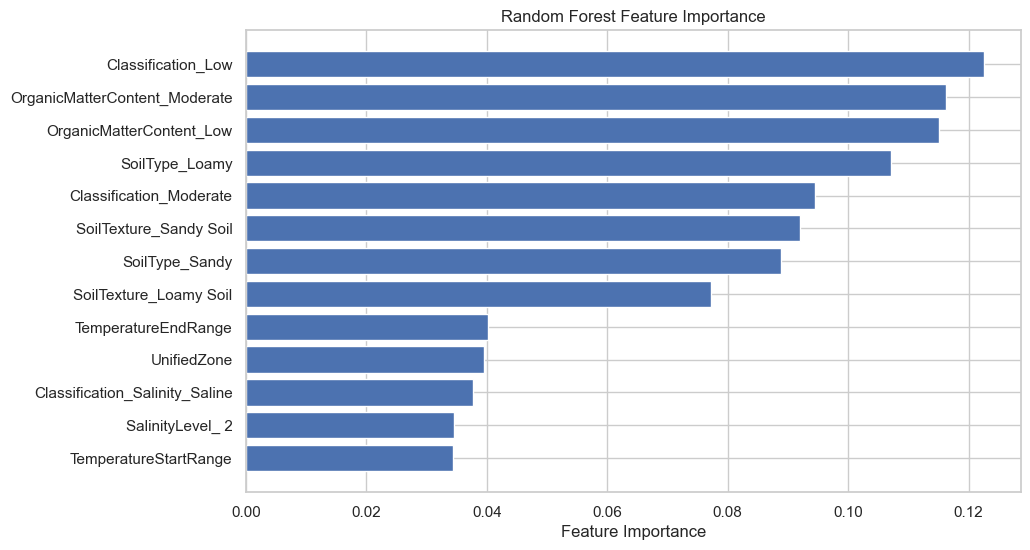

In [19]:
import matplotlib.pyplot as plt
import numpy as np

# Assuming `rf_model` is your trained Random Forest model
feature_importances = rf_model.feature_importances_

# Sort feature importances in descending order
sorted_idx = np.argsort(feature_importances)[::-1]

# Plot feature importance
plt.figure(figsize=(10, 6))
plt.barh(range(len(feature_importances)), feature_importances[sorted_idx], align='center')
plt.yticks(range(len(feature_importances)), np.array(X_encoded.columns)[sorted_idx])
plt.gca().invert_yaxis()  # Invert y-axis to display top features at the top
plt.xlabel('Feature Importance')
plt.title('Random Forest Feature Importance')
plt.show()


In [20]:
cleaned_df.PlantType.value_counts()

PlantType
Fruit        673
Vegetable    671
Herb         658
Name: count, dtype: int64

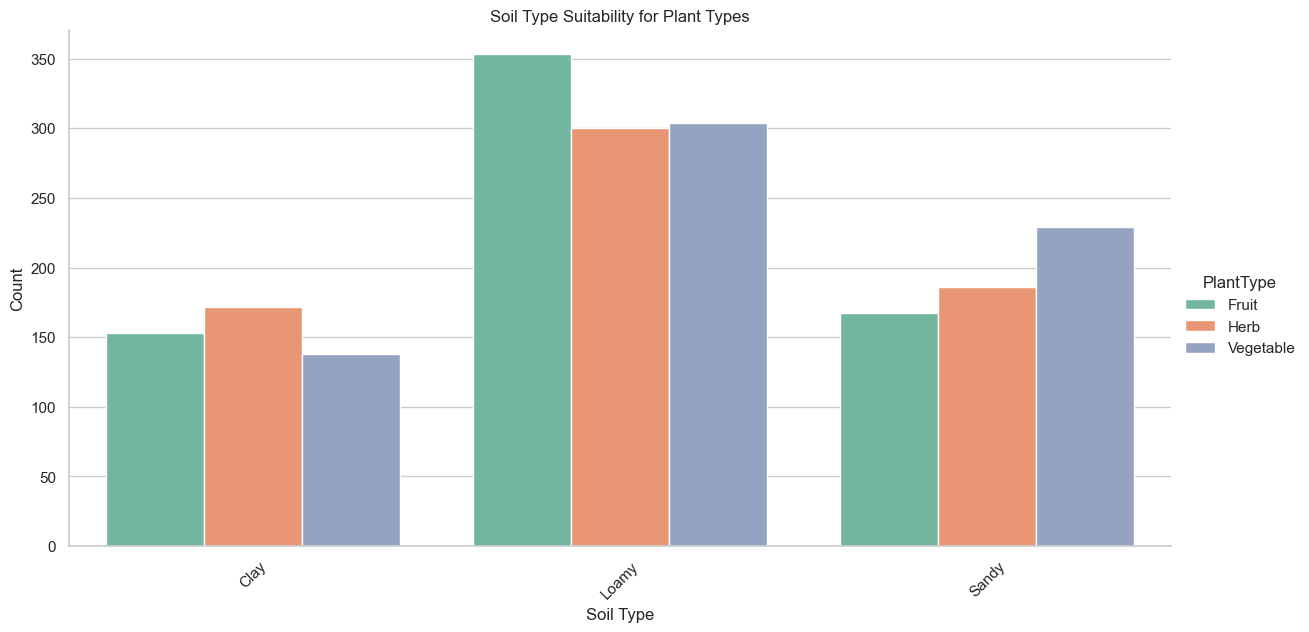

In [21]:
sns.catplot(
    data=cleaned_df, 
    x="SoilType", 
    hue="PlantType", 
    kind="count", 
    height=6, 
    aspect=2, 
    palette="Set2"
)
plt.title('Soil Type Suitability for Plant Types')
plt.ylabel('Count')
plt.xlabel('Soil Type')
plt.xticks(rotation=45)
plt.show()

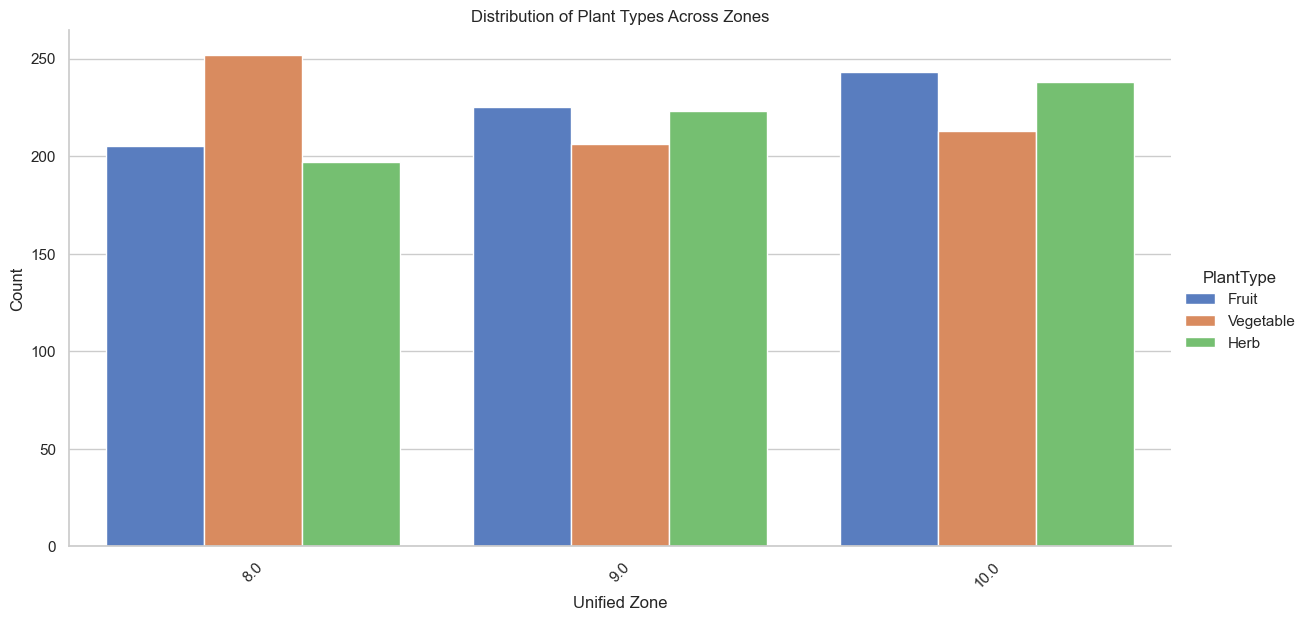

In [22]:
sns.catplot(
    x='UnifiedZone', 
    hue='PlantType', 
    kind='count', 
    data=cleaned_df, 
    height=6, 
    aspect=2, 
    palette='muted'
)
plt.title('Distribution of Plant Types Across Zones')
plt.ylabel('Count')
plt.xlabel('Unified Zone')
plt.xticks(rotation=45)
plt.show()